#EDA

In [ ]:
# Mengimpor library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Menghubungkan Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("Library dan Google Drive siap digunakan!")

Mounted at /content/drive
Library dan Google Drive siap digunakan!


In [ ]:
# Memuat dataset
file_path = '/content/drive/My Drive/Colab Notebooks/Tugas3ML/heart.csv'
df = pd.read_csv(file_path)

# Menampilkan 5 baris pertama
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
# Menampilkan informasi dataset
print("Informasi Dataset:")
df.info()

# Menampilkan jumlah missing values
print("\nJumlah Missing Values per Kolom:")
print(df.isnull().sum())

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB

Jumlah Missing Values per Kolom:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR    

In [ ]:
# Statistik deskriptif untuk fitur numerik
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
print("Statistik Deskriptif untuk Fitur Numerik:")
df[numeric_cols].describe()

Statistik Deskriptif untuk Fitur Numerik:


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
count,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,136.809368,0.887364
std,9.432617,18.514154,109.384145,25.460334,1.066570
min,28.000000,0.000000,0.000000,60.000000,-2.600000
25%,47.000000,120.000000,173.250000,120.000000,0.000000
50%,54.000000,130.000000,223.000000,138.000000,0.600000
75%,60.000000,140.000000,267.000000,156.000000,1.500000
max,77.000000,200.000000,603.000000,202.000000,6.200000


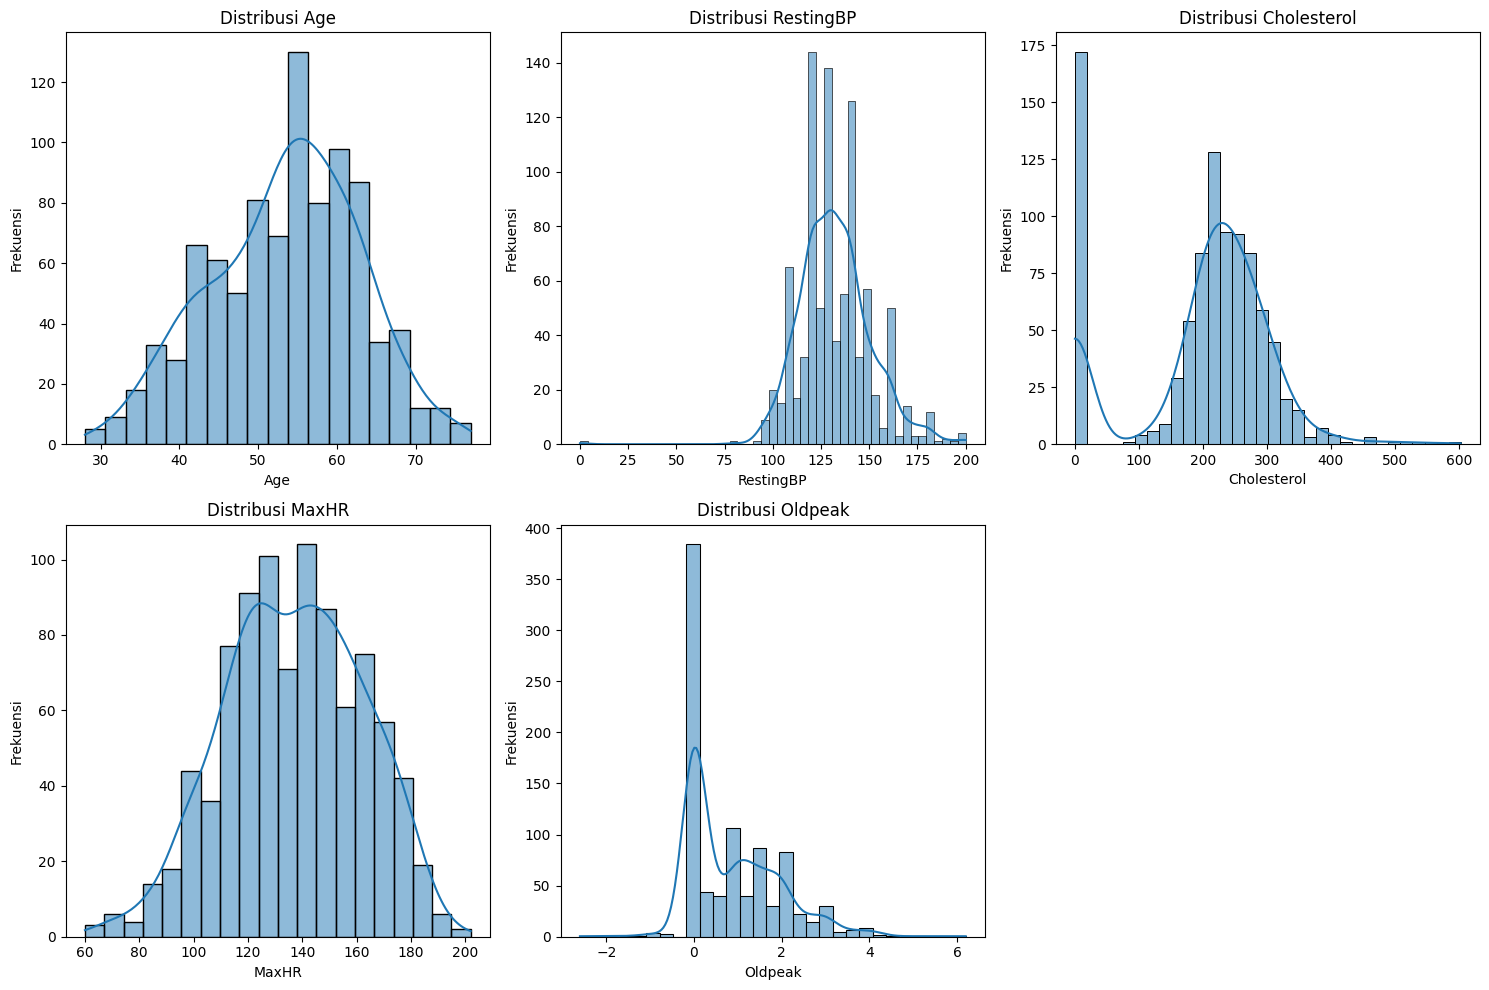

In [ ]:
# Membuat histogram untuk fitur numerik
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

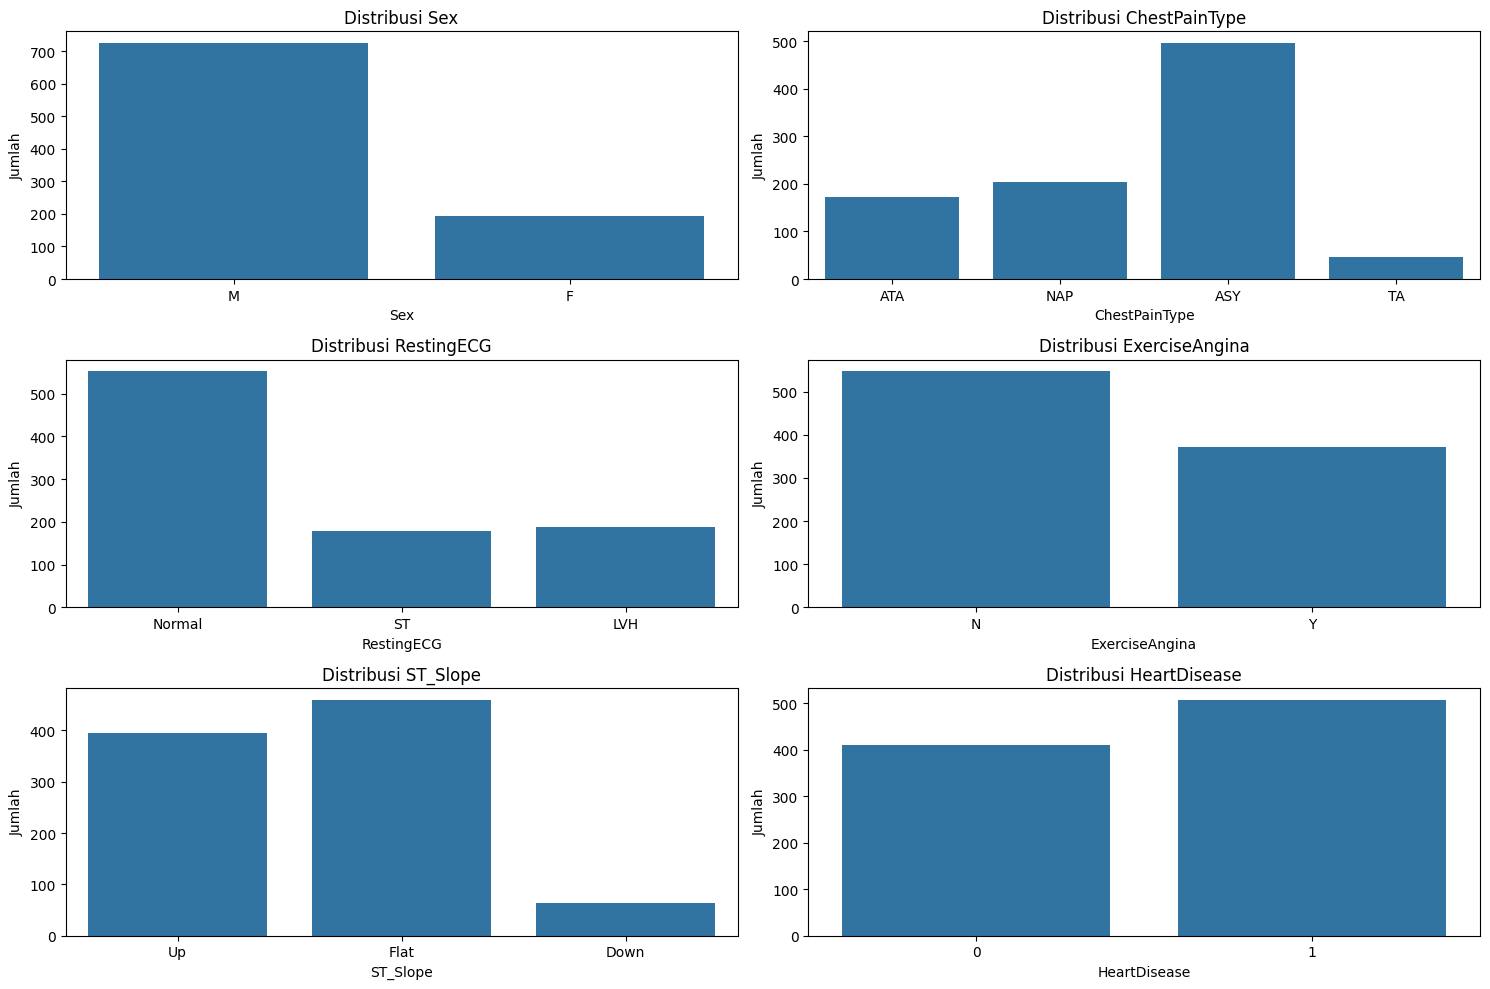

In [ ]:
# Fitur kategorikal
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']

# Membuat countplot
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 2, i)
    sns.countplot(x=col, data=df)
    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()

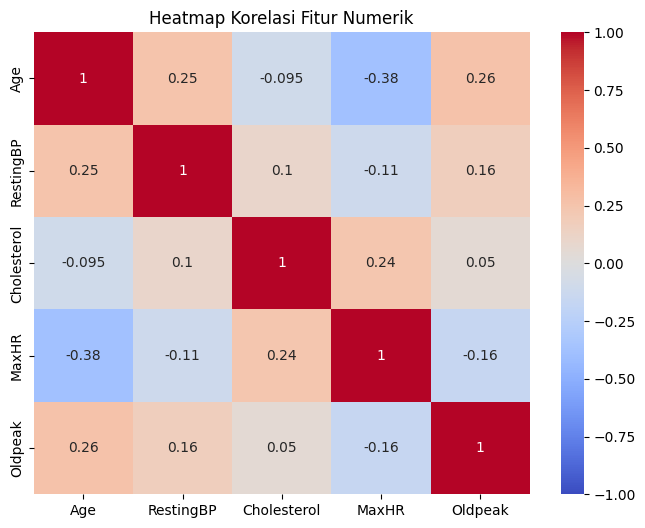

In [ ]:
# Menghitung matriks korelasi
corr_matrix = df[numeric_cols].corr()

# Membuat heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Fitur Numerik')
plt.show()

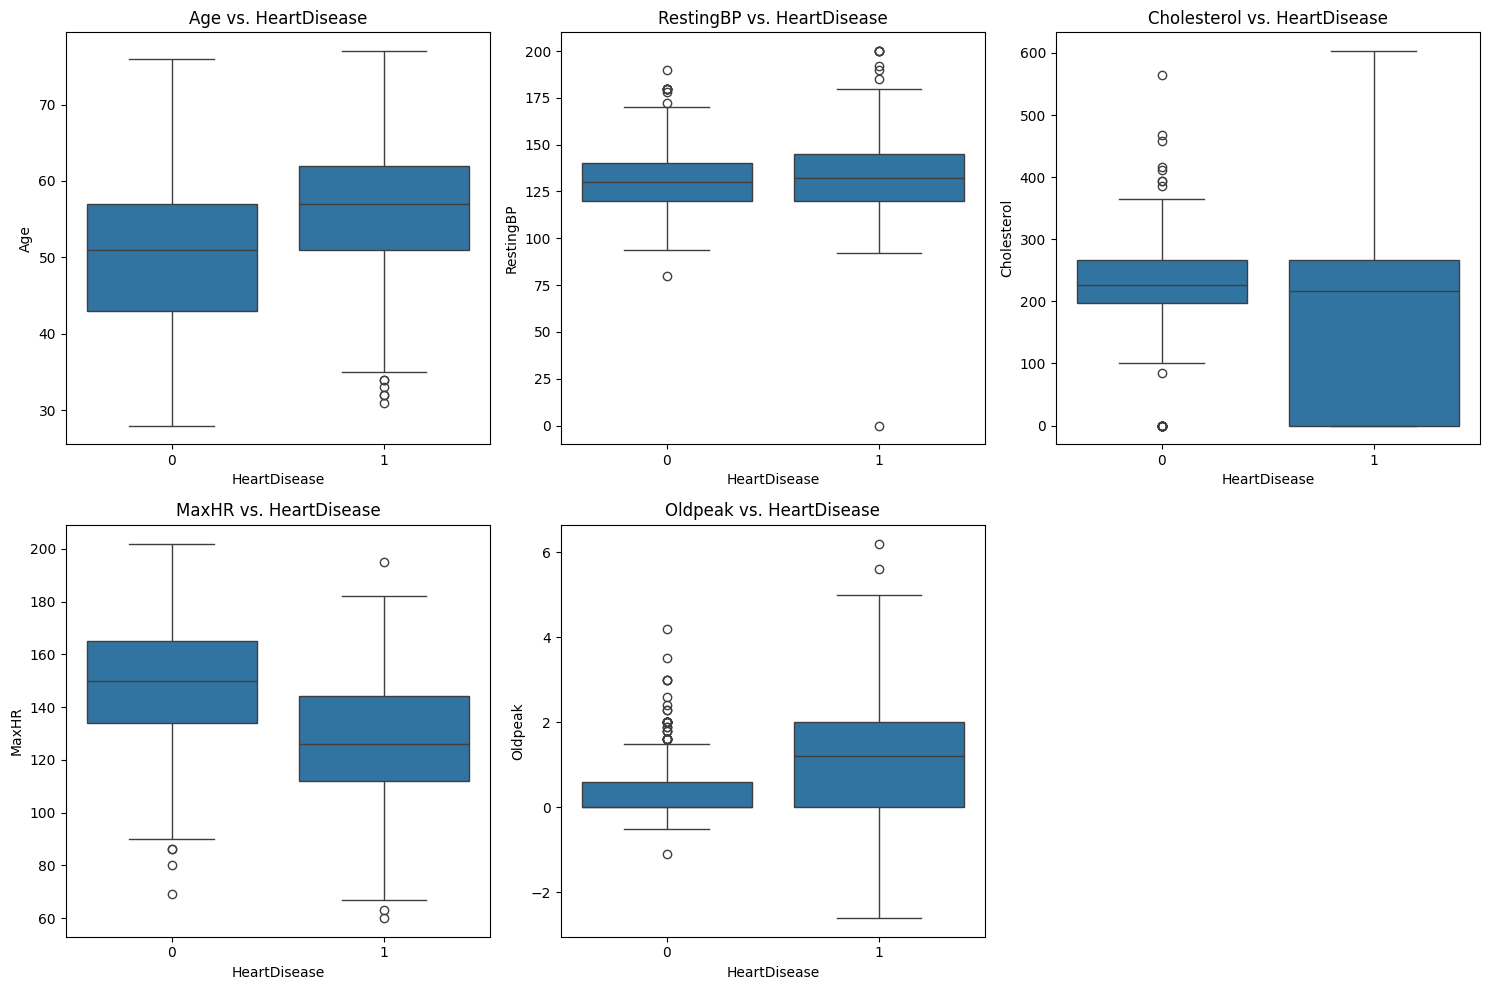

In [ ]:
# Membuat boxplot
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='HeartDisease', y=col, data=df)
    plt.title(f'{col} vs. HeartDisease')
    plt.xlabel('HeartDisease')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

# Data Cleaning


## Cell 9: Penanganan Nilai 0 pada RestingBP dan Cholesterol
Mengganti nilai 0 pada RestingBP dan Cholesterol dengan median kolom masing-masing.

In [ ]:
# Menampilkan jumlah nilai 0 sebelum penggantian
print("Jumlah nilai 0 sebelum penggantian:")
print(f"RestingBP: {len(df[df['RestingBP'] == 0])}")
print(f"Cholesterol: {len(df[df['Cholesterol'] == 0])}")

# Mengganti nilai 0 dengan median
df['RestingBP'] = df['RestingBP'].replace(0, df['RestingBP'].median())
df['Cholesterol'] = df['Cholesterol'].replace(0, df['Cholesterol'].median())

# Verifikasi setelah penggantian
print("\nJumlah nilai 0 setelah penggantian:")
print(f"RestingBP: {len(df[df['RestingBP'] == 0])}")
print(f"Cholesterol: {len(df[df['Cholesterol'] == 0])}")

Jumlah nilai 0 sebelum penggantian:
RestingBP: 1
Cholesterol: 172

Jumlah nilai 0 setelah penggantian:
RestingBP: 0
Cholesterol: 0


## Cell 10: Encoding Fitur Kategorikal
Mengubah fitur kategorikal menjadi numerik menggunakan One-Hot Encoding.

In [ ]:
# Fitur kategorikal
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

# One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Menampilkan 5 baris pertama setelah encoding
df_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


## Cell 11: Normalisasi Fitur Numerik
Menormalisasi fitur numerik menggunakan StandardScaler.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Fitur numerik
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

# Inisialisasi scaler
scaler = StandardScaler()

# Normalisasi
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

# Menampilkan 5 baris pertama setelah normalisasi
df_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.415002,0.897407,0,1.382928,-0.832432,0,True,True,False,False,True,False,False,False,True
1,-0.478484,1.527329,-1.122849,0,0.754157,0.105664,1,False,False,True,False,True,False,False,True,False
2,-1.751359,-0.141161,0.786200,0,-1.525138,-0.832432,0,True,True,False,False,False,True,False,False,True
3,-0.584556,0.303769,-0.492677,0,-1.132156,0.574711,1,False,False,False,False,True,False,True,True,False
4,0.051881,0.971166,-0.844832,0,-0.581981,-0.832432,0,True,False,True,False,True,False,False,False,True


# Model Prep

## Cell 12: Membagi Data Menjadi Train dan Test
Membagi dataset menjadi data latih (80%) dan data uji (20%) menggunakan train-test split.

In [ ]:
from sklearn.model_selection import train_test_split

# Memisahkan fitur (X) dan target (y)
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

# Membagi data menjadi train dan test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Menampilkan ukuran data
print("Ukuran Data:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

Ukuran Data:
X_train: (734, 15)
X_test: (184, 15)
y_train: (734,)
y_test: (184,)


## Cell 13: Implementasi Logistic Regression
Membangun model Logistic Regression, melatih model, membuat prediksi, dan mengevaluasi performa.

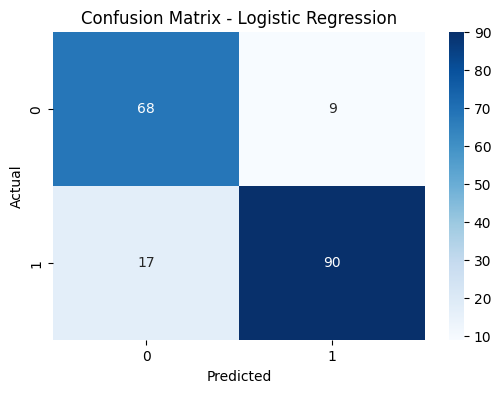

Classification Report - Logistic Regression:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84        77
           1       0.91      0.84      0.87       107

    accuracy                           0.86       184
   macro avg       0.85      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184

Log Loss - Logistic Regression: 0.3556


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, log_loss
import seaborn as sns
import matplotlib.pyplot as plt

# Inisialisasi dan melatih model
logreg = LogisticRegression(random_state=42)
logreg.fit(X_train, y_train)

# Membuat prediksi
y_pred_logreg = logreg.predict(X_test)
y_pred_prob_logreg = logreg.predict_proba(X_test)

# Menghitung Confusion Matrix
cm_logreg = confusion_matrix(y_test, y_pred_logreg)

# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Menampilkan Classification Report
print("Classification Report - Logistic Regression:")
print(classification_report(y_test, y_pred_logreg))

# Menghitung Loss Value (Log Loss)
loss_logreg = log_loss(y_test, y_pred_prob_logreg)
print(f"Log Loss - Logistic Regression: {loss_logreg:.4f}")

## Cell 14: Implementasi K-Nearest Neighbor (K-NN)
Membangun model K-NN dengan k=5, melatih model, membuat prediksi, dan mengevaluasi performa.

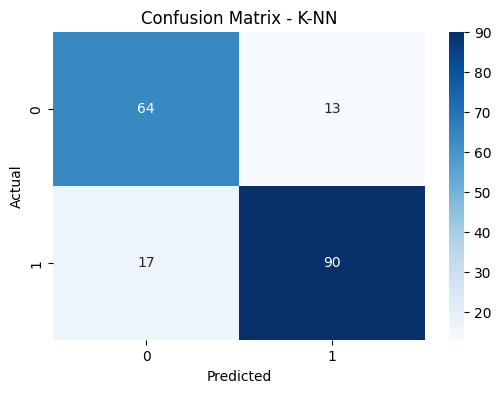

Classification Report - K-NN:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81        77
           1       0.87      0.84      0.86       107

    accuracy                           0.84       184
   macro avg       0.83      0.84      0.83       184
weighted avg       0.84      0.84      0.84       184



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Inisialisasi dan melatih model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Membuat prediksi
y_pred_knn = knn.predict(X_test)

# Menghitung Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - K-NN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Menampilkan Classification Report
print("Classification Report - K-NN:")
print(classification_report(y_test, y_pred_knn))

## Cell 15: Implementasi Naïve Bayes
Membangun model Gaussian Naïve Bayes, melatih model, membuat prediksi, dan mengevaluasi performa.

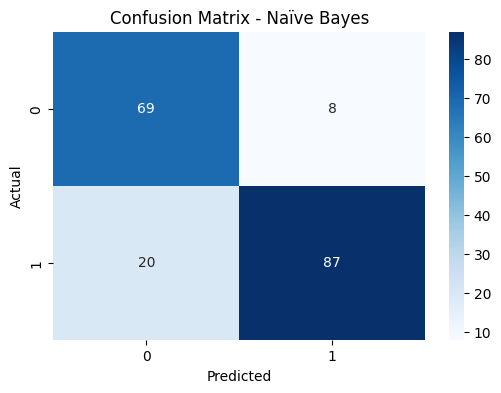

Classification Report - Naïve Bayes:
              precision    recall  f1-score   support

           0       0.78      0.90      0.83        77
           1       0.92      0.81      0.86       107

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.86      0.85      0.85       184



In [ ]:
from sklearn.naive_bayes import GaussianNB

# Inisialisasi dan melatih model
nb = GaussianNB()
nb.fit(X_train, y_train)

# Membuat prediksi
y_pred_nb = nb.predict(X_test)

# Menghitung Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Naïve Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Menampilkan Classification Report
print("Classification Report - Naïve Bayes:")
print(classification_report(y_test, y_pred_nb))

## Cell 16: Implementasi Decision Tree
Membangun model Decision Tree, melatih model, membuat prediksi, dan mengevaluasi performa.

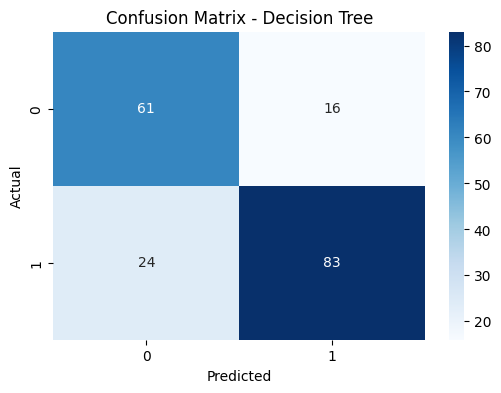

Classification Report - Decision Tree:
              precision    recall  f1-score   support

           0       0.72      0.79      0.75        77
           1       0.84      0.78      0.81       107

    accuracy                           0.78       184
   macro avg       0.78      0.78      0.78       184
weighted avg       0.79      0.78      0.78       184



In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Inisialisasi dan melatih model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Membuat prediksi
y_pred_dt = dt.predict(X_test)

# Menghitung Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Menampilkan Classification Report
print("Classification Report - Decision Tree:")
print(classification_report(y_test, y_pred_dt))

## Cell 17: Membandingkan Performa Model
Mengumpulkan metrik performa dari keempat model dan membandingkannya dalam tabel dan bar chart.

Perbandingan Performa Model:
                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.858696   0.909091  0.841121  0.873786
1                 K-NN  0.836957   0.873786  0.841121  0.857143
2          Naïve Bayes  0.847826   0.915789  0.813084  0.861386
3        Decision Tree  0.782609   0.838384  0.775701  0.805825


<Figure size 1000x600 with 0 Axes>

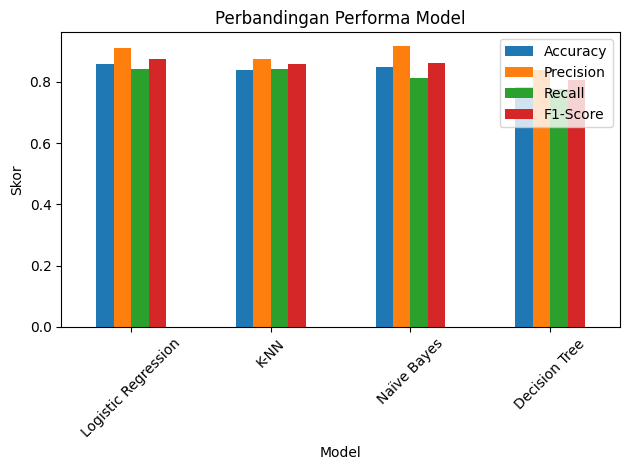

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Mengumpulkan metrik performa
models = ['Logistic Regression', 'K-NN', 'Naïve Bayes', 'Decision Tree']
predictions = [y_pred_logreg, y_pred_knn, y_pred_nb, y_pred_dt]

# Menghitung metrik untuk setiap model
results = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}

for model, y_pred in zip(models, predictions):
    results['Model'].append(model)
    results['Accuracy'].append(accuracy_score(y_test, y_pred))
    results['Precision'].append(precision_score(y_test, y_pred))
    results['Recall'].append(recall_score(y_test, y_pred))
    results['F1-Score'].append(f1_score(y_test, y_pred))

# Membuat DataFrame untuk hasil
results_df = pd.DataFrame(results)

# Menampilkan tabel perbandingan
print("Perbandingan Performa Model:")
print(results_df)

# Visualisasi perbandingan performa
plt.figure(figsize=(10, 6))
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(kind='bar')
plt.title('Perbandingan Performa Model')
plt.ylabel('Skor')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

Model Terbaik: Logistic Regression adalah model terbaik berdasarkan metrik ini, dengan Accuracy tertinggi (0.858696), F1-Score tertinggi (0.873786), dan keseimbangan yang baik antara Precision (0.909091) dan Recall (0.841121). Model ini sangat cocok untuk prediksi penyakit jantung karena dapat mendeteksi sebagian besar pasien sakit sambil meminimalkan False Positives.
Model Alternatif: K-NN juga menunjukkan performa yang sangat baik, dengan metrik yang hampir setara dengan Logistic Regression. Naïve Bayes unggul dalam Precision, tetapi Recall yang lebih rendah membuatnya kurang ideal dalam konteks medis.
Model Terburuk: Decision Tree memiliki performa terendah di semua metrik, kemungkinan karena overfitting. Model ini kurang cocok untuk kasus ini tanpa penyesuaian lebih lanjut (misalnya, hyperparameter tuning).
Kualitas Model Secara Keseluruhan: Ketiga model (Logistic Regression, K-NN, Naïve Bayes) memiliki performa yang cukup baik untuk memprediksi risiko penyakit jantung, dengan Accuracy di atas 83% dan F1-Score di atas 0.85. Namun, Decision Tree perlu ditingkatkan untuk mencapai performa yang setara.

## Cell 19: Menghitung Probabilitas Prediksi untuk ROC Curve
Melatih ulang model dan menghitung probabilitas prediksi pada data uji untuk keempat model.

In [ ]:
# Inisialisasi model (menggunakan model yang sudah dilatih sebelumnya)
logreg = LogisticRegression(random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
nb = GaussianNB()
dt = DecisionTreeClassifier(random_state=42)

# Melatih model
logreg.fit(X_train, y_train)
knn.fit(X_train, y_train)
nb.fit(X_train, y_train)
dt.fit(X_train, y_train)

# Menghitung probabilitas prediksi
y_pred_prob_logreg = logreg.predict_proba(X_test)[:, 1]
y_pred_prob_knn = knn.predict_proba(X_test)[:, 1]
y_pred_prob_nb = nb.predict_proba(X_test)[:, 1]
y_pred_prob_dt = dt.predict_proba(X_test)[:, 1]

print("Probabilitas prediksi untuk ROC Curve telah dihitung.")

Probabilitas prediksi untuk ROC Curve telah dihitung.


## Cell 20: Membuat dan Menampilkan ROC Curve
Menghitung ROC Curve dan AUC untuk keempat model, lalu menampilkan dalam satu plot.

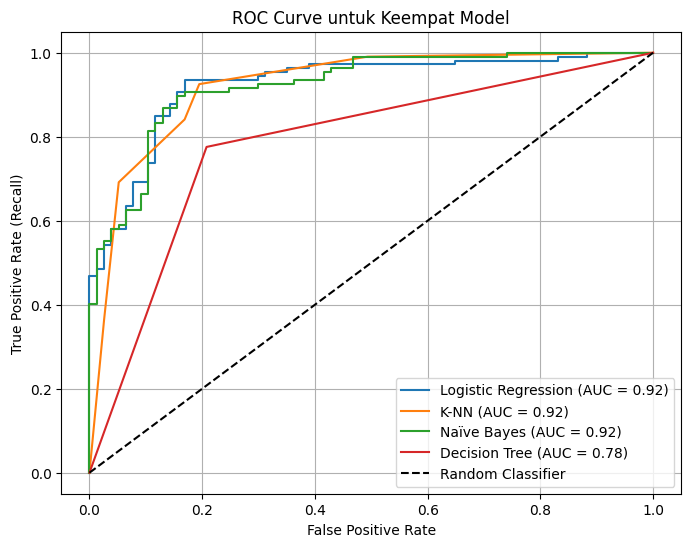

In [ ]:
from sklearn.metrics import roc_curve, auc

# Menghitung ROC Curve dan AUC
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_pred_prob_logreg)
auc_logreg = auc(fpr_logreg, tpr_logreg)

fpr_knn, tpr_knn, _ = roc_curve(y_test, y_pred_prob_knn)
auc_knn = auc(fpr_knn, tpr_knn)

fpr_nb, tpr_nb, _ = roc_curve(y_test, y_pred_prob_nb)
auc_nb = auc(fpr_nb, tpr_nb)

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_prob_dt)
auc_dt = auc(fpr_dt, tpr_dt)

# Membuat plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_logreg, tpr_logreg, label=f'Logistic Regression (AUC = {auc_logreg:.2f})')
plt.plot(fpr_knn, tpr_knn, label=f'K-NN (AUC = {auc_knn:.2f})')
plt.plot(fpr_nb, tpr_nb, label=f'Naïve Bayes (AUC = {auc_nb:.2f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.2f})')

# Menambahkan garis diagonal (random classifier)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

# Pengaturan plot
plt.title('ROC Curve untuk Keempat Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

1. Nilai AUC
Logistic Regression (AUC = 0.92): AUC tertinggi, menunjukkan performa terbaik dalam membedakan pasien dengan penyakit jantung (1) dan tanpa penyakit jantung (0).
K-NN (AUC = 0.92): AUC sama dengan Logistic Regression, menunjukkan performa yang setara dalam hal kemampuan diskriminasi.
Naïve Bayes (AUC = 0.92): AUC juga sama dengan Logistic Regression dan K-NN, menunjukkan performa yang sangat baik dan setara.
Decision Tree (AUC = 0.78): AUC terendah di antara keempat model, tetapi masih jauh di atas 0.5, menunjukkan bahwa model ini tetap lebih baik dari tebakan acak, meskipun performanya lebih rendah dibandingkan model lain.